<a href="https://colab.research.google.com/github/NischalDragneel-77/DataScience_512_Assignment2/blob/main/Assignment2_DataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assigment - 2

In [ ]:
from IPython.display import HTML
display(HTML("<style>pre {white-space: pre-wrap !important}</style>"))

## 1. Problem Statement and Background

Online retailers collect a lot of information about how customers interact with their websites, such as which products people look at, add to their cart, remove from their cart, and finally buy. Looking at these interactions is important because it helps us know what customers like, makes it easier to turn more visitors into buyers, and helps the business run smoothly.

This project looks at how online shoppers interact with products, buy things, and move through their shopping experience to find common trends. The study looks into finding out which product groups get the most attention, how customers interact at different times, and if customers buy items from categories or products they have looked at before. It also looks at how people re-engage with their carts, like adding a product back into the cart after taking it out.

The results can help an online store better suggest products, plan their marketing, manage stock more effectively, and increase the number of customers who make purchases. The analysis uses Python tools to process and visualize customer event data, turning it into useful business insights.

## 2.	Resources

### a. Data Source

The dataset used in this project is “Ecommerce behavior data from multi-category store”, published on Kaggle by mkechinov.

Source: [Kaggle – Ecommerce behavior data from multi-category store](https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store?select=2019-Oct.csv)

The analysis uses the 2019-Oct.csv file, which contains e-commerce events collected during October 2019. Due to the large size of the dataset, a random sample of the data is used for analysis.

### b. Characteristics of the Data

In [ ]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 3.	Business Model:

### a.	Research questions:  
Through analysis we will try to answer foloowing research questions:  

RQ1: Which product categories have the highest levels of views, cart additions, and purchases?  
RQ2: How does customer activity vary by hour of the day and day of the week?  
RQ3: What proportion of product views progress to cart additions and purchases, and where are the major conversion drop-offs?  
RQ4: What percentage of user sessions move from product discovery to final purchase?

### Drive Mount and Loading Data

In [ ]:
import os
import shutil
import zipfile
from google.colab import files
import pandas as pd
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# mount google drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create assignment data folder
# Define the base path to the folder containing datasets in Google Drive
data_dir = '/content/drive/MyDrive/MDA512DS/MDA512_Assignment/data'
os.makedirs(data_dir, exist_ok=True)

In [ ]:
import pandas as pd

#Load ONLY the first 10,000,000 rows for initial inspection
initial_size = 1_000_000

data_file = os.path.join(data_dir, "2019-Oct.csv")

print(f"\nLoading first {initial_size} rows of 2019-Oct.csv...")

df = pd.read_csv(
    data_file
)

print("\nDataset sample loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nData information:")
df.info()


Loading first 1000000 rows of 2019-Oct.csv...

Dataset sample loaded successfully!
Shape: (42448764, 9)

First 5 rows:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d



Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.8+ GB


###Initial data inspection

In [ ]:
# Statistical summary
print("\n--- Numerical Summary ---")
print(df.describe())

# Unique values
print("\n--- Unique Values ---")
print("Users:", df["user_id"].nunique())
print("Products:", df["product_id"].nunique())
print("Categories:", df["category_id"].nunique())
print("Brands:", df["brand"].nunique())
print("Sessions:", df["user_session"].nunique())

# Event distribution
print("\n--- Event Types ---")
print(df["event_type"].value_counts())

# Missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Numerical Summary ---
         product_id   category_id         price       user_id
count  4.244876e+07  4.244876e+07  4.244876e+07  4.244876e+07
mean   1.054993e+07  2.057404e+18  2.903237e+02  5.335371e+08
std    1.188191e+07  1.843926e+16  3.582692e+02  1.852374e+07
min    1.000978e+06  2.053014e+18  0.000000e+00  3.386938e+07
25%    1.005157e+06  2.053014e+18  6.598000e+01  5.159043e+08
50%    5.000470e+06  2.053014e+18  1.629300e+02  5.296965e+08
75%    1.600030e+07  2.053014e+18  3.585700e+02  5.515788e+08
max    6.050001e+07  2.175420e+18  2.574070e+03  5.662809e+08

--- Unique Values ---
Users: 3022290
Products: 166794
Categories: 624
Brands: 3444
Sessions: 9244421

--- Event Types ---
event_type
view        40779399
cart          926516
purchase      742849
Name: count, dtype: int64

--- Missing Values ---
event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price       

###Data preprocessing

In [ ]:
# Convert event_time to datetime
df["event_time"] = pd.to_datetime(df["event_time"], utc=True)

# Create useful time variables
df["hour"] = df["event_time"].dt.hour
df["day_of_week"] = df["event_time"].dt.day_name()
df["date"] = df["event_time"].dt.date

# Check result
print(df[["event_time", "hour", "day_of_week", "date"]].head())

                 event_time  hour day_of_week        date
0 2019-10-01 00:00:00+00:00     0     Tuesday  2019-10-01
1 2019-10-01 00:00:00+00:00     0     Tuesday  2019-10-01
2 2019-10-01 00:00:01+00:00     0     Tuesday  2019-10-01
3 2019-10-01 00:00:01+00:00     0     Tuesday  2019-10-01
4 2019-10-01 00:00:04+00:00     0     Tuesday  2019-10-01


###Handle missing categories and brands

In [ ]:
# Replace missing categorical values
df["category_code"] = df["category_code"].fillna("Unknown")
df["brand"] = df["brand"].fillna("Unknown")

print(df.isnull().sum())

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     2
hour             0
day_of_week      0
date             0
dtype: int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

###Cleaner category variable

In [ ]:
df["main_category"] = df["category_code"].str.split(".").str[0]

df["main_category"] = df["main_category"].fillna("Unknown")

print(df["main_category"].value_counts())

main_category
electronics     16135623
Unknown         13515609
appliances       4967294
computers        2324217
apparel          1542924
furniture        1247160
auto             1013115
construction      730834
kids              520619
accessories       238238
sport             176616
medicine           14806
country_yard       14089
stationery          7620
Name: count, dtype: int64


### RQ1 — Category performance
Count views, carts and purchases by category

In [ ]:
category_events = pd.crosstab(
    df["main_category"],
    df["event_type"]
)

In [ ]:
for event in ["view", "cart", "purchase"]:
    if event not in category_events.columns:
        category_events[event] = 0

category_events = category_events[["view", "cart", "purchase"]]

In [ ]:
top_categories = (
    category_events
    .sort_values("view", ascending=False)
)
print(top_categories)

event_type         view    cart  purchase
main_category                            
electronics    15038390  674205    423028
Unknown        13236458  105726    173425
appliances      4799936   92362     74996
computers       2268928   27434     27855
apparel         1534896      26      8002
furniture       1236452    2407      8301
auto             993428    9067     10620
construction     712690   10343      7801
kids             512485    2652      5482
accessories      236102     549      1587
sport            174324    1056      1236
medicine          13974     522       310
country_yard      13956      61        72
stationery         7380     106       134


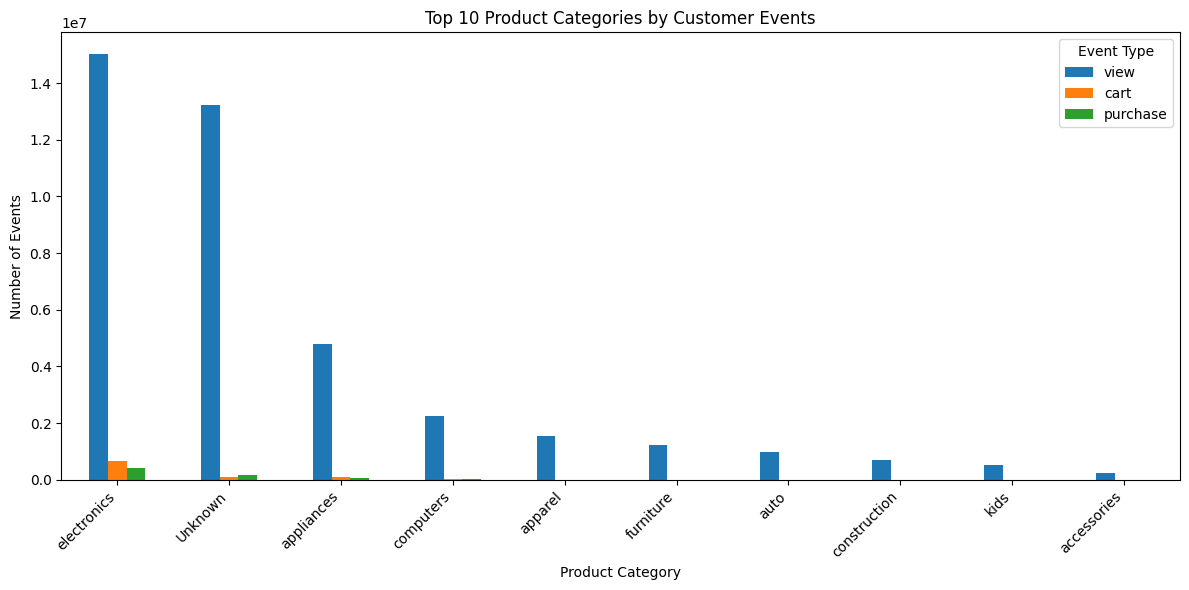

In [ ]:
top10 = top_categories.head(10)

top10.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top 10 Product Categories by Customer Events")
plt.xlabel("Product Category")
plt.ylabel("Number of Events")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Event Type")
plt.tight_layout()
plt.show()

### RQ2 - Customer activity variation by hour of the day and day of the week

In [ ]:
hourly_events = pd.crosstab(
    df["hour"],
    df["event_type"]
)

for event in ["view", "cart", "purchase"]:
    if event not in hourly_events.columns:
        hourly_events[event] = 0

hourly_events = hourly_events[["view", "cart", "purchase"]]

print(hourly_events)

event_type     view   cart  purchase
hour                                
0            299874   3982      2949
1            545742   7759      5526
2           1037315  17764     13968
3           1485926  34725     29634
4           1826454  48043     41146
5           2020538  57024     48071
6           2154468  62619     52005
7           2217746  64566     53406
8           2267899  67031     55197
9           2229264  67236     55183
10          2181560  63713     51904
11          2086826  59758     47311
12          2040927  55053     41888
13          2263632  52222     39138
14          2590385  50802     37363
15          2892601  50657     37632
16          2972082  46888     35773
17          2663340  39505     30873
18          2069720  30918     24325
19          1304238  20184     16748
20           722821  11511      9892
21           425189   6955      6278
22           264826   4392      3837
23           216026   3209      2802


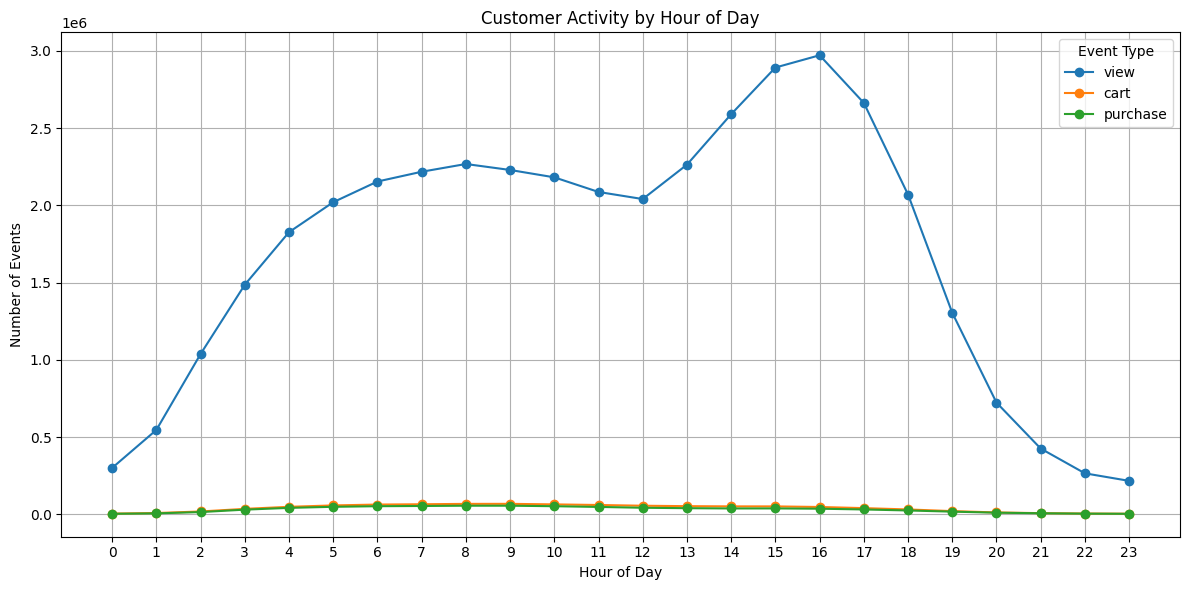

In [ ]:
hourly_events.plot(
    figsize=(12, 6),
    marker="o"
)

plt.title("Customer Activity by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Events")
plt.xticks(range(24))
plt.grid(True)
plt.legend(title="Event Type")
plt.tight_layout()
plt.show()

In [ ]:
peak_view_hour = hourly_events["view"].idxmax()
peak_cart_hour = hourly_events["cart"].idxmax()
peak_purchase_hour = hourly_events["purchase"].idxmax()

print(
    f"Peak view hour: {peak_view_hour}:00 "
    f"({hourly_events.loc[peak_view_hour, 'view']:,} views)"
)

print(
    f"Peak cart hour: {peak_cart_hour}:00 "
    f"({hourly_events.loc[peak_cart_hour, 'cart']:,} carts)"
)

print(
    f"Peak purchase hour: {peak_purchase_hour}:00 "
    f"({hourly_events.loc[peak_purchase_hour, 'purchase']:,} purchases)"
)

Peak view hour: 16:00 (2,972,082 views)
Peak cart hour: 9:00 (67,236 carts)
Peak purchase hour: 8:00 (55,197 purchases)


In [ ]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_events = pd.crosstab(
    df["day_of_week"],
    df["event_type"]
)

for event in ["view", "cart", "purchase"]:
    if event not in daily_events.columns:
        daily_events[event] = 0

daily_events = daily_events.reindex(day_order)

print(daily_events)

event_type     cart  purchase     view
day_of_week                           
Monday       117423     96062  5108044
Tuesday      139056    114510  6548319
Wednesday    134382    119159  6398991
Thursday     131219    113664  6135484
Friday       142238    103044  5584378
Saturday     130429     96177  5380190
Sunday       131769    100233  5623993


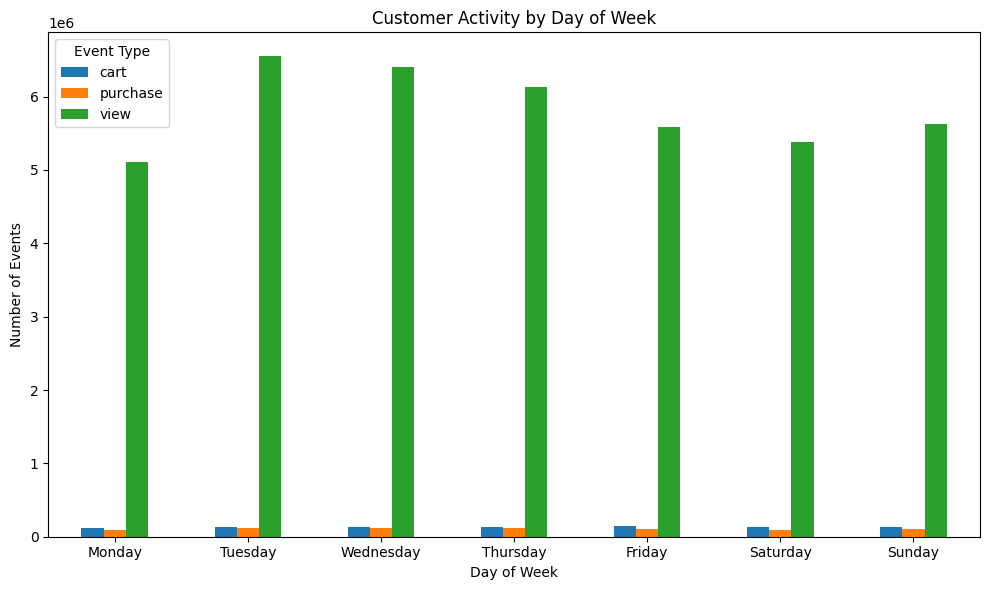

In [ ]:
daily_events.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Activity by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.legend(title="Event Type")
plt.tight_layout()
plt.show()

### RQ3 - Conversion Ratios

In [ ]:
event_counts = df["event_type"].value_counts()

views = event_counts.get("view", 0)
carts = event_counts.get("cart", 0)
purchases = event_counts.get("purchase", 0)

view_to_cart = carts / views * 100
cart_to_purchase = purchases / carts * 100
view_to_purchase = purchases / views * 100

print(f"View → Cart: {view_to_cart:.2f}%")
print(f"Cart → Purchase: {cart_to_purchase:.2f}%")
print(f"View → Purchase: {view_to_purchase:.2f}%")

View → Cart: 2.27%
Cart → Purchase: 80.18%
View → Purchase: 1.82%


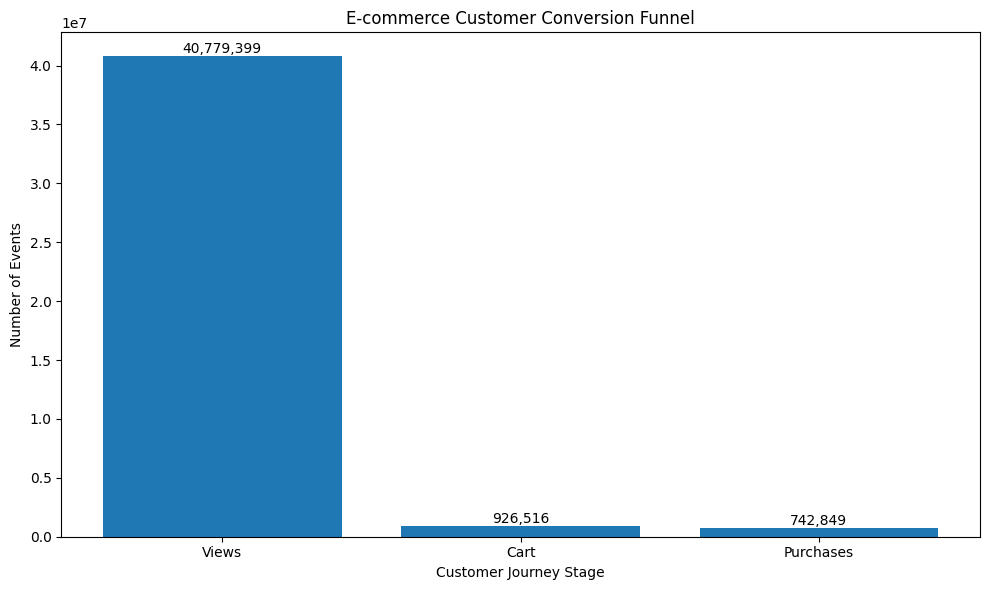

In [ ]:
funnel_labels = ["Views", "Cart", "Purchases"]
funnel_values = [views, carts, purchases]

plt.figure(figsize=(10, 6))

plt.bar(
    funnel_labels,
    funnel_values
)

plt.title("E-commerce Customer Conversion Funnel")
plt.xlabel("Customer Journey Stage")
plt.ylabel("Number of Events")

for i, value in enumerate(funnel_values):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
view_to_cart_dropoff = 100 - view_to_cart
cart_to_purchase_dropoff = 100 - cart_to_purchase

print(
    f"View → Cart drop-off: "
    f"{view_to_cart_dropoff:.2f}%"
)

print(
    f"Cart → Purchase drop-off: "
    f"{cart_to_purchase_dropoff:.2f}%"
)

View → Cart drop-off: 97.73%
Cart → Purchase drop-off: 19.82%


In [ ]:
category_analysis = category_events.copy()

category_analysis["view_to_cart_rate"] = np.where(
    category_analysis["view"] > 0,
    category_analysis["cart"] / category_analysis["view"] * 100,
    0
)

category_analysis["view_to_purchase_rate"] = np.where(
    category_analysis["view"] > 0,
    category_analysis["purchase"] / category_analysis["view"] * 100,
    0
)

print(category_analysis.sort_values(
    "view_to_purchase_rate",
    ascending=False
))

event_type         view    cart  purchase  view_to_cart_rate  \
main_category                                                  
electronics    15038390  674205    423028           4.483226   
medicine          13974     522       310           3.735509   
stationery         7380     106       134           1.436314   
appliances      4799936   92362     74996           1.924234   
Unknown        13236458  105726    173425           0.798748   
computers       2268928   27434     27855           1.209117   
construction     712690   10343      7801           1.451262   
kids             512485    2652      5482           0.517479   
auto             993428    9067     10620           0.912698   
sport            174324    1056      1236           0.605769   
accessories      236102     549      1587           0.232527   
furniture       1236452    2407      8301           0.194670   
apparel         1534896      26      8002           0.001694   
country_yard      13956      61        7

In [ ]:
category_funnel = pd.crosstab(
    df["main_category"],
    df["event_type"]
)

for event in ["view", "cart", "purchase"]:
    if event not in category_funnel.columns:
        category_funnel[event] = 0

category_funnel["view_to_cart_%"] = np.where(
    category_funnel["view"] > 0,
    category_funnel["cart"] /
    category_funnel["view"] * 100,
    0
)

category_funnel["view_to_purchase_%"] = np.where(
    category_funnel["view"] > 0,
    category_funnel["purchase"] /
    category_funnel["view"] * 100,
    0
)

category_funnel["cart_to_purchase_%"] = np.where(
    category_funnel["cart"] > 0,
    category_funnel["purchase"] /
    category_funnel["cart"] * 100,
    0
)

print(category_funnel.sort_values(
    "view_to_purchase_%",
    ascending=False
))

event_type       cart  purchase      view  view_to_cart_%  view_to_purchase_%  \
main_category                                                                   
electronics    674205    423028  15038390        4.483226            2.812987   
medicine          522       310     13974        3.735509            2.218406   
stationery        106       134      7380        1.436314            1.815718   
appliances      92362     74996   4799936        1.924234            1.562437   
Unknown        105726    173425  13236458        0.798748            1.310207   
computers       27434     27855   2268928        1.209117            1.227672   
construction    10343      7801    712690        1.451262            1.094585   
kids             2652      5482    512485        0.517479            1.069690   
auto             9067     10620    993428        0.912698            1.069026   
sport            1056      1236    174324        0.605769            0.709025   
accessories       549      1

In [ ]:
category_funnel_filtered = category_funnel[
    category_funnel["view"] >= 100
].sort_values(
    "view_to_purchase_%",
    ascending=False
)

print(category_funnel_filtered)

event_type       cart  purchase      view  view_to_cart_%  view_to_purchase_%  \
main_category                                                                   
electronics    674205    423028  15038390        4.483226            2.812987   
medicine          522       310     13974        3.735509            2.218406   
stationery        106       134      7380        1.436314            1.815718   
appliances      92362     74996   4799936        1.924234            1.562437   
Unknown        105726    173425  13236458        0.798748            1.310207   
computers       27434     27855   2268928        1.209117            1.227672   
construction    10343      7801    712690        1.451262            1.094585   
kids             2652      5482    512485        0.517479            1.069690   
auto             9067     10620    993428        0.912698            1.069026   
sport            1056      1236    174324        0.605769            0.709025   
accessories       549      1

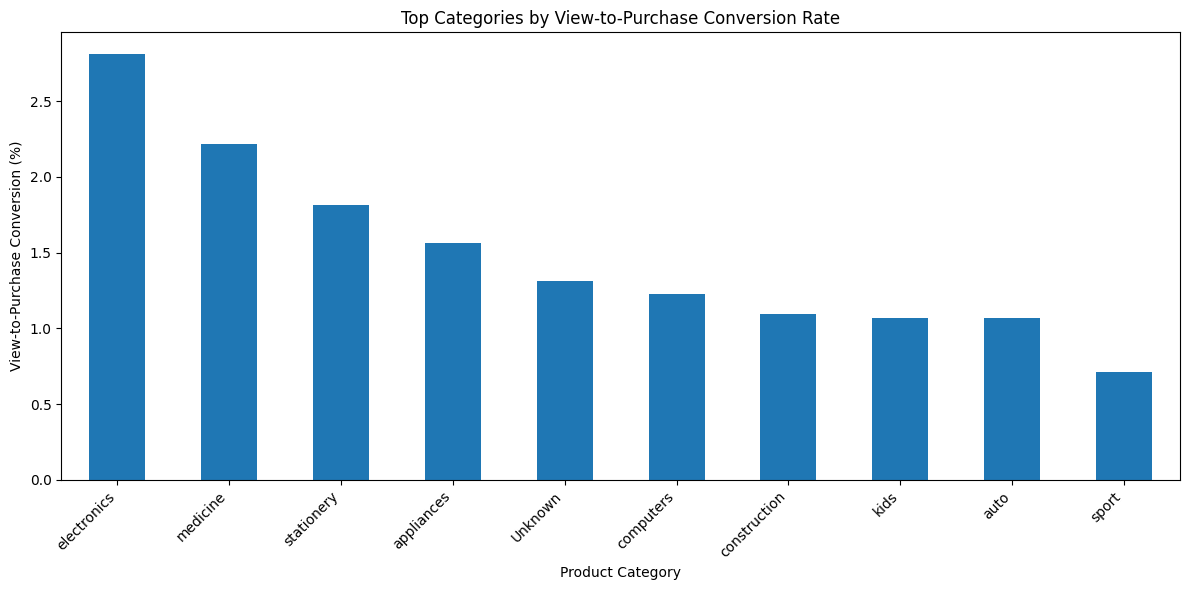

In [ ]:
top_conversion_categories = category_funnel_filtered.head(10)

top_conversion_categories["view_to_purchase_%"].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top Categories by View-to-Purchase Conversion Rate")
plt.xlabel("Product Category")
plt.ylabel("View-to-Purchase Conversion (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
hour_funnel = pd.crosstab(
    df["hour"],
    df["event_type"]
)

for event in ["view", "cart", "purchase"]:
    if event not in hour_funnel.columns:
        hour_funnel[event] = 0

hour_funnel["view_to_purchase_%"] = np.where(
    hour_funnel["view"] > 0,
    hour_funnel["purchase"] /
    hour_funnel["view"] * 100,
    0
)

print(hour_funnel)

event_type   cart  purchase     view  view_to_purchase_%
hour                                                    
0            3982      2949   299874            0.983413
1            7759      5526   545742            1.012566
2           17764     13968  1037315            1.346553
3           34725     29634  1485926            1.994312
4           48043     41146  1826454            2.252781
5           57024     48071  2020538            2.379119
6           62619     52005  2154468            2.413821
7           64566     53406  2217746            2.408121
8           67031     55197  2267899            2.433839
9           67236     55183  2229264            2.475391
10          63713     51904  2181560            2.379215
11          59758     47311  2086826            2.267127
12          55053     41888  2040927            2.052401
13          52222     39138  2263632            1.728991
14          50802     37363  2590385            1.442372
15          50657     37632  28

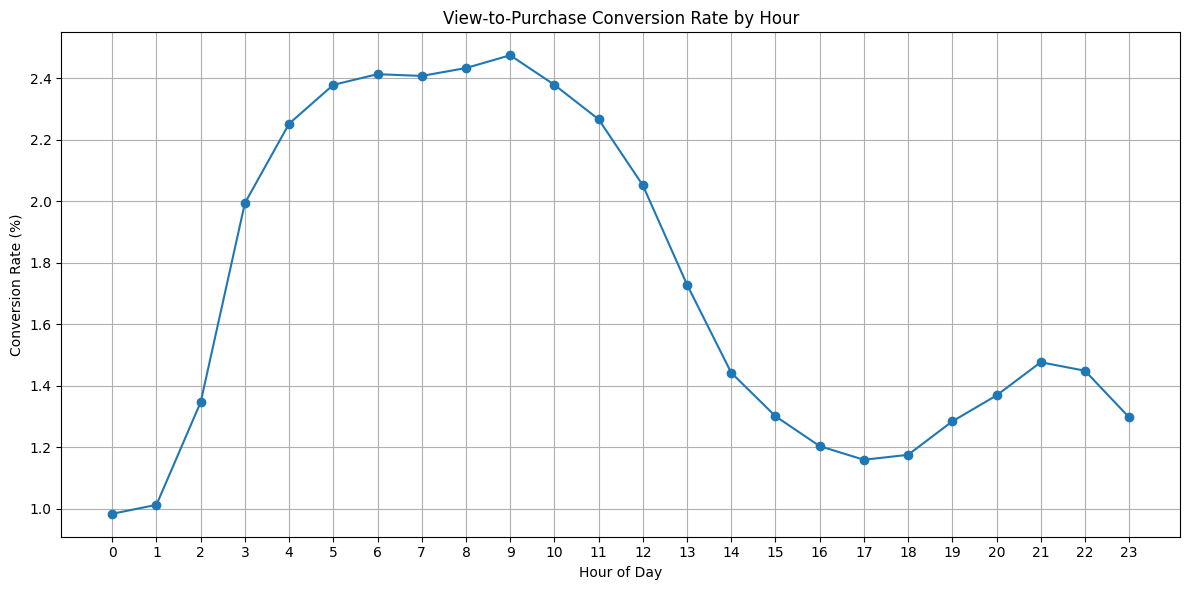

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    hour_funnel.index,
    hour_funnel["view_to_purchase_%"],
    marker="o"
)

plt.title("View-to-Purchase Conversion Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Conversion Rate (%)")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

### R4 - DID VIEWED PRODUCTS GET PURCHASED?

In [ ]:
# Step 1: Convert time format and sort events sequentially
df["event_time"] = pd.to_datetime(
    df["event_time"],
    utc=True
)

df = df.sort_values(
    ["user_session", "event_time"]
).reset_index(drop=True)

print("DataFrame sorted by user_session and event_time successfully.")

DataFrame sorted by user_session and event_time successfully.


In [ ]:
# Step 2: Research Question - Did viewed products get purchased?
# Create sets of event types for each product within each session
session_product_events = (
    df.groupby(
        ["user_session", "product_id"]
    )["event_type"]
    .agg(set)
    .reset_index()
)

display(session_product_events.head())

,user_session,product_id,event_type
0,00000042-3e3f-42f9-810d-f3d264139c50,54900011,{view}
1,00000056-a206-40dd-b174-a072550fa38c,1003312,{view}
2,00000056-a206-40dd-b174-a072550fa38c,1004858,{view}
3,00000056-a206-40dd-b174-a072550fa38c,1005104,{view}
4,00000056-a206-40dd-b174-a072550fa38c,1005105,{view}


In [ ]:
# Step 3: Identify viewed and purchased flags for each session-product
session_product_events["viewed"] = (
    session_product_events["event_type"]
    .apply(lambda x: "view" in x)
)

session_product_events["purchased"] = (
    session_product_events["event_type"]
    .apply(lambda x: "purchase" in x)
)

viewed_purchased = session_product_events[
    (session_product_events["viewed"]) &
    (session_product_events["purchased"])
]

print(
    "Viewed and subsequently purchased products in same session:",
    len(viewed_purchased)
)

Viewed and subsequently purchased products in same session: 689117


In [ ]:
# Step 4: Calculate the product-level conversion rate
total_viewed_products = session_product_events[
    session_product_events["viewed"]
]

if len(total_viewed_products) > 0:
    view_purchase_rate = (
        len(viewed_purchased)
        / len(total_viewed_products)
        * 100
    )
else:
    view_purchase_rate = 0.0

print(f"Viewed -> Purchased rate: {view_purchase_rate:.2f}%")

Viewed -> Purchased rate: 2.48%


In [ ]:
import numpy as np
import pandas as pd
import os

# Re-define df and data_dir for self-sufficiency in case of kernel reset
data_dir = '/content/drive/MyDrive/MDA512DS/MDA512_Assignment/data'
data_file = os.path.join(data_dir, "2019-Oct.csv")
df = pd.read_csv(data_file)

# Filter active events to avoid working with irrelevant data during grouping
views_df = df[df["event_type"] == "view"]
purchases_df = df[df["event_type"] == "purchase"]

# Vectorized aggregation using groupby to construct sets extremely fast
print("Grouping and aggregating viewed products...")
viewed_sets = views_df.groupby("user_session")["product_id"].agg(set)

print("Grouping and aggregating purchased products...")
purchased_sets = purchases_df.groupby("user_session")["product_id"].agg(set)

# Combine them into a single summary DataFrame
session_summary = pd.DataFrame(index=df["user_session"].dropna().unique())
session_summary["viewed_products"] = session_summary.index.map(viewed_sets).fillna(value=set())
session_summary["purchased_products"] = session_summary.index.map(purchased_sets).fillna(value=set())
session_summary = session_summary.reset_index().rename(columns={"index": "user_session"})

# Fill NaN values with empty sets safely
session_summary["viewed_products"] = session_summary["viewed_products"].apply(lambda d: d if isinstance(d, set) else set())
session_summary["purchased_products"] = session_summary["purchased_products"].apply(lambda d: d if isinstance(d, set) else set())

# Vectorized same-product checks to avoid row-by-row apply loops
session_summary["same_product_purchase"] = [
    len(v & p) > 0 for v, p in zip(session_summary["viewed_products"], session_summary["purchased_products"])
]

# Vectorized different-product checks
session_summary["different_product_purchase"] = [
    len(p) > 0 and len(v & p) == 0 for v, p in zip(session_summary["viewed_products"], session_summary["purchased_products"])
]

print("\nSame product purchase counts:")
print(session_summary["same_product_purchase"].value_counts())

print("\nDifferent product purchase counts:")
print(session_summary["different_product_purchase"].value_counts())

Grouping and aggregating viewed products...


In [ ]:
# Step 6: Category behavior analysis
session_category = (
    df.groupby("user_session")
    .agg(
        viewed_categories=(
            "category_id",
            lambda x: set(
                x[
                    df.loc[x.index, "event_type"]
                    == "view"
                ]
            )
        ),
        purchased_categories=(
            "category_id",
            lambda x: set(
                x[
                    df.loc[x.index, "event_type"]
                    == "purchase"
                ]
            )
        )
    )
    .reset_index()
)

session_category["same_category_purchase"] = (
    session_category.apply(
        lambda row:
        len(
            row["viewed_categories"]
            & row["purchased_categories"]
        ) > 0,
        axis=1
    )
)

session_category["different_category_purchase"] = (
    session_category.apply(
        lambda row:
        len(row["purchased_categories"]) > 0
        and len(
            row["viewed_categories"]
            & row["purchased_categories"]
        ) == 0,
        axis=1
    )
)

print("Category behavior overlap summary:")
print(session_category[["same_category_purchase", "different_category_purchase"]].sum())

In [ ]:
# Step 7: Create customer journey group segments
total_sessions = len(session_category)

same_category = session_category[
    "same_category_purchase"
].sum()

different_category = session_category[
    "different_category_purchase"
].sum()

purchase_sessions = (
    session_category["purchased_categories"]
    .apply(len) > 0
).sum()

view_only = total_sessions - purchase_sessions

print("Total sessions:", total_sessions)
print(f"View only: {view_only} ({view_only / total_sessions * 100:.2f}%)")
print(f"Same-category purchase: {same_category} ({same_category / total_sessions * 100:.2f}%)")
print(f"Different-category purchase: {different_category} ({different_category / total_sessions * 100:.2f}%)")

In [ ]:

# Ensure event_time is in datetime format and sort events properly
df["event_time"] = pd.to_datetime(
    df["event_time"],
    utc=True
)

df = df.sort_values(
    ["user_session", "event_time"]
).reset_index(drop=True)

print("DataFrame sorted by session and event time successfully.")

In [ ]:
# Create sets of event types for each product within each session
session_product_events = (
    df.groupby(
        ["user_session", "product_id"]
    )["event_type"]
    .agg(set)
    .reset_index()
)

print("\n--- Session Product Events Sample ---")
print(session_product_events.head())


In [ ]:
session_product_events["viewed"] = (
    session_product_events["event_type"]
    .apply(lambda x: "view" in x)
)

session_product_events["purchased"] = (
    session_product_events["event_type"]
    .apply(lambda x: "purchase" in x)
)

viewed_purchased = session_product_events[
    (session_product_events["viewed"]) &
    (session_product_events["purchased"])
]

print(
    "\nViewed and subsequently purchased products in the same session:",
    len(viewed_purchased)
)

In [ ]:
total_viewed_products = session_product_events[
    session_product_events["viewed"]
]

if len(total_viewed_products) > 0:
    view_purchase_rate = (
        len(viewed_purchased)
        / len(total_viewed_products)
        * 100
    )
else:
    view_purchase_rate = 0.0

print(
    f"\nViewed -> Purchased rate (Product-level): "
    f"{view_purchase_rate:.2f}%"
)

In [ ]:
# Keep only required columns to reduce memory usage
events = df[["user_session", "product_id", "event_type"]]

# Separate views and purchases
views = (
    events[events["event_type"].eq("view")]
    [["user_session", "product_id"]]
    .drop_duplicates()
)

purchases = (
    events[events["event_type"].eq("purchase")]
    [["user_session", "product_id"]]
    .drop_duplicates()
)

# Find products that were both viewed and purchased
same_product = views.merge(
    purchases,
    on=["user_session", "product_id"],
    how="inner"
)

# Sessions with at least one same-product purchase
same_sessions = same_product["user_session"].unique()

# Sessions with at least one purchase
purchase_sessions = purchases["user_session"].unique()

# Sessions that purchased, but none of their purchased products
# matched their viewed products
different_sessions = set(purchase_sessions) - set(same_sessions)

# Create summary
session_summary = pd.DataFrame({
    "user_session": purchase_sessions
})

session_summary["same_product_purchase"] = (
    session_summary["user_session"].isin(same_sessions)
)

session_summary["different_product_purchase"] = (
    session_summary["user_session"].isin(different_sessions)
)

print("\n--- Same Product Purchase Value Counts ---")
print(session_summary["same_product_purchase"].value_counts())

print("\n--- Different Product Purchase Value Counts ---")
print(session_summary["different_product_purchase"].value_counts())

In [ ]:
# Create masks once
view_mask = df["event_type"].eq("view")
purchase_mask = df["event_type"].eq("purchase")

# Group categories by session and event type
session_category = (
    df.assign(
        viewed_category=df["category_id"].where(view_mask),
        purchased_category=df["category_id"].where(purchase_mask)
    )
    .groupby("user_session")
    .agg(
        viewed_categories=(
            "viewed_category",
            lambda x: set(x.dropna())
        ),
        purchased_categories=(
            "purchased_category",
            lambda x: set(x.dropna())
        )
    )
    .reset_index()
)

# Calculate overlap using list comprehension (faster than apply(axis=1))
overlap = [
    viewed & purchased
    for viewed, purchased in zip(
        session_category["viewed_categories"],
        session_category["purchased_categories"]
    )
]

session_category["same_category_purchase"] = [
    len(x) > 0 for x in overlap
]

session_category["different_category_purchase"] = [
    len(purchased) > 0 and len(common) == 0
    for purchased, common in zip(
        session_category["purchased_categories"],
        overlap
    )
]

print("\n--- Same vs Different Category Purchases Summary ---")
print(
    session_category[
        [
            "same_category_purchase",
            "different_category_purchase"
        ]
    ].sum()
)

In [ ]:

total_sessions = len(session_category)

same_category = session_category[
    "same_category_purchase"
].sum()

different_category = session_category[
    "different_category_purchase"
].sum()

purchase_sessions = (
    session_category["purchased_categories"]
    .apply(len) > 0
).sum()

view_only = total_sessions - purchase_sessions

print("\n--- Customer Journey Groups Analysis ---")
print("Total sessions:", total_sessions)
print("View only:", view_only)
print("Same-category purchase:", same_category)
print("Different-category purchase:", different_category)

print("\n--- Percentages ---")
print(f"View only: {view_only / total_sessions * 100:.2f}%")
print(f"Same-category purchase: {same_category / total_sessions * 100:.2f}%")
print(f"Different-category purchase: {different_category / total_sessions * 100:.2f}%")

### b. Challenges

- The dataset was large, so only the first 1,000,000 rows were loaded due to memory limitations.
- Missing values existed in `category_code` and `brand`.
- Duplicate records and different event types made conversion analysis difficult.
- The sample mainly contained Tuesday data, limiting day-of-week analysis.

### c. Data Pre-processing

- Loaded the dataset using `pandas.read_csv()` with `nrows=1_000_000`.
- Converted `event_time` into datetime format.
- Created new features: `hour`, `day_of_week`, `date`, and `main_category`.
- Replaced missing values in `category_code` and `brand` with `"Unknown"`.
- Checked data types, missing values, duplicates, unique values, and event counts.
- Used grouping and cross-tabulation for analysis.


### d. Use of Dataset for Business Requirements

- Identified categories with the highest views, cart additions, and purchases.
- Found peak customer activity times to support business scheduling.
- Calculated view-to-cart and view-to-purchase rates to identify customer drop-offs.
- Analysed customer sessions to determine whether users purchased viewed products or products from the same category.
- Electronics had the highest overall activity.
- Most sessions were view-only, showing a significant opportunity to improve conversion.


### e. Methodologies and Algorithms

### Methodologies Used

- Descriptive statistics
- Frequency analysis
- Grouping and aggregation
- Cross-tabulation
- Conversion-rate calculation
- Set-based session analysis

No machine-learning algorithm was used because the research questions focused on descriptive and exploratory analysis.

### Python Libraries and Commands

- **Pandas:** `read_csv()`, `info()`, `describe()`, `isnull()`, `nunique()`, `value_counts()`, `groupby()`, `agg()`, `crosstab()`, and `sort_values()`
- **NumPy:** Used for numerical calculations.
- **Matplotlib:** Used for data visualisation.
- **OS:** Used for file and directory handling.
- **Google Colab Drive:** Used to access the dataset stored in Google Drive.

# please format below this

## 4. Data Analysis

### a. Goals of the Analysis

The main goal of the analysis was to understand customer behaviour in an e-commerce platform and identify opportunities to improve sales and customer conversion.

The analysis focused on the following goals:

- Identify product categories with the highest views, cart additions, and purchases.
- Determine the hours when customer activity is highest.
- Measure the proportion of views that lead to cart additions and purchases.
- Analyse whether customers purchase products they viewed or products from the same category.

The success metrics included the number of views, cart additions, purchases, conversion rates, and the percentage of sessions resulting in purchases.

### b. Data Analytics Tools and Python Libraries

The project was implemented in Google Colab using Python.

- **Pandas:** Used for data loading, cleaning, preprocessing, grouping, aggregation, and analysis.
- **NumPy:** Used for numerical calculations.
- **Matplotlib:** Used to create charts and visualisations.
- **OS:** Used for handling file paths and accessing the dataset.
- **Google Drive:** Used to store and access the dataset.

Important Pandas functions included `read_csv()`, `groupby()`, `value_counts()`, `crosstab()`, `sort_values()`, `isnull()`, and `nunique()`.

### c. Analysis, Visualisations, and Business Understanding

#### Product Category Analysis

A cross-tabulation was used to compare views, cart additions, and purchases across product categories. A bar chart can be used because it makes differences between categories easy to compare.

The results showed that **electronics** had the highest number of views, cart additions, and purchases. This indicates strong customer interest and suggests that the business should maintain product availability and marketing efforts in this category.

#### Time-Based Customer Activity

Customer activity was grouped by hour and visualised using bar charts. Bar charts were selected to clearly compare activity levels across different hours.

The highest number of views occurred at **15:00**, while cart additions peaked at **08:00** and purchases peaked at **09:00**. These results can help the business plan marketing campaigns, staffing, promotions, and system resources around periods of high activity.

#### Conversion Analysis

Conversion rates were calculated to examine the movement from product views to cart additions and purchases.

- View-to-cart rate: **1.51%**
- View-to-purchase rate: **1.74%**

The low conversion rates suggest that many customers view products without completing a purchase. The business could investigate product pricing, product information, website usability, and checkout processes to reduce customer drop-off.

#### Session and Customer Journey Analysis

Customer sessions were analysed by comparing viewed and purchased products and categories. Grouping and set-based comparisons were used to identify whether purchases occurred within the same product category.

The results showed that:

- **93.68%** of sessions were view-only.
- **6.28%** of sessions involved a purchase from the same category as a viewed product.
- **0.04%** of sessions involved a purchase from a different category.

This suggests that most sessions do not result in purchases. The business could improve recommendations, personalised offers, product suggestions, and remarketing strategies to encourage customers to complete purchases.

## 5. Results

### 1.1 Product Category Analysis

A cross-tabulation was used to compare views, cart additions, and purchases across product categories. A bar chart was selected because it clearly shows differences in customer activity between categories.

The results showed that **electronics** had the highest activity, with:

- 363,833 views
- 12,321 cart additions
- 9,890 purchases

This indicates strong customer interest in electronics. The business could prioritise stock availability, promotions, and marketing for this category.

### 1.2 Customer Activity by Hour

Customer events were grouped by hour and analysed using bar charts. This visualisation was selected to compare customer activity across different times of the day.

The results showed:

- Highest views: **15:00**, with 91,425 views
- Highest cart additions: **08:00**, with 1,390 cart additions
- Highest purchases: **09:00**, with 1,478 purchases

These findings can help the business schedule promotions, customer support, and system resources during periods of high activity.

### 1.3 Conversion Analysis

Conversion rates were calculated to measure customer movement from product views to cart additions and purchases.

| Conversion Metric | Result |
|---|---:|
| View-to-cart rate | 1.51% |
| View-to-purchase rate | 1.74% |

The low conversion rates indicate that many customers view products without purchasing them. The business could investigate product pricing, product descriptions, website usability, and the checkout process to reduce customer drop-off.

The cart-to-purchase percentage was 115.09%. However, this should not be treated as a true conversion rate because purchases may occur without a recorded cart event and the analysis uses event counts rather than matched customer journeys.

### 1.4 Customer Session Analysis

Customer sessions were analysed by grouping viewed and purchased products and categories. Set-based comparisons were used to identify whether customers purchased products from categories they had previously viewed.

The results showed:

| Session Type | Number | Percentage |
|---|---:|---:|
| View-only sessions | 212,058 | 93.68% |
| Same-category purchase sessions | 14,226 | 6.28% |
| Different-category purchase sessions | 90 | 0.04% |

Most sessions were view-only, indicating a significant opportunity to improve customer conversion. Personalised recommendations, related-product suggestions, targeted discounts, and remarketing could encourage customers to complete purchases.

### 1.5 Evaluation of Analytical Methods

Several descriptive analytical methods were used and compared:

- **Value counts:** Used to identify the frequency of event types and customer activity.
- **Cross-tabulation:** Used to compare product categories and event types.
- **Group-by aggregation:** Used to analyse customer activity by hour and session.
- **Set-based comparison:** Used to compare viewed and purchased products or categories within sessions.
- **Bar charts:** Used because the results involved comparisons between discrete categories and time periods.

These methods were suitable because the research questions focused on understanding customer behaviour, category performance, and conversion patterns rather than predicting future outcomes using machine-learning algorithms.

### 1.6 Evidence and Code Appendix

Important Python code fragments, such as the code for category analysis, conversion calculations, and session analysis, can be included in this section to support the reported results.

The complete Python program, including data loading, preprocessing, analysis, and visualisation code, should be attached as **Appendix A**.